# Интеллектуальный анализ данных – весна 2026

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [145]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
print(round(-(8/10 * np.log(8/10) + 2/10 * np.log(2/10)), 2))

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [146]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
print(round(0.8*0.2+0.2*0.8 - 8/10 * (1*0+0*1) - 2/10 * (0*1+1*0), 2))

0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [147]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
print(np.mean([1, 10, 5, 18, 100, 30, 50, 61, 84, 47]))

40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [148]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [149]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(———
    n = len(feature_vector)
    feature_vector = np.array(feature_vector)
    target_vector = np.array(target_vector)
    if feature_type == "real":
        idx_sort = np.argsort(feature_vector)
        f_new = feature_vector[idx_sort]
        t_new = target_vector[idx_sort]
        uniq, counts = np.unique(f_new, return_counts=True)
        thr = (uniq[:-1] + uniq[1:]) / 2
        split_idx = np.cumsum(counts)[:-1]
        n_left = split_idx
        n_right = n - n_left
        if task == "regression":
            Hm = np.var(t_new)
            cumsum = np.cumsum(t_new)
            cumsum_sq = np.cumsum(t_new ** 2)
            sum_left = cumsum[split_idx - 1]
            sum_sq_left = cumsum_sq[split_idx - 1]
            Hl = sum_sq_left / n_left - (sum_left / n_left) ** 2
            Hr = (cumsum_sq[-1] - sum_sq_left) / n_right - ((cumsum[-1] - sum_left) / n_right) ** 2
        else:
            classes = np.unique(target_vector)
            one_hot = (t_new.reshape(-1, 1) == classes.reshape(1, -1))
            cumcounts = np.cumsum(one_hot, axis=0)
            left_counts = cumcounts[split_idx - 1, :]
            right_counts = cumcounts[-1, :] - left_counts
            p_total = one_hot.mean(axis=0)
            Hm = np.sum(p_total * (1 - p_total))
            p_left = left_counts / n_left[:, np.newaxis]
            p_right = right_counts / n_right[:, np.newaxis]
            Hl = np.sum(p_left * (1 - p_left), axis=1)
            Hr = np.sum(p_right * (1 - p_right), axis=1)
    else:
        uniq, counts = np.unique(feature_vector, return_counts=True)
        thr = uniq
        n_left = counts
        n_right = n - n_left
        classes = np.unique(target_vector)
        f_oh = (feature_vector.reshape(-1, 1) == uniq.reshape(1, -1))
        t_oh = (target_vector.reshape(-1, 1) == classes.reshape(1, -1))
        left_counts = f_oh.T @ t_oh
        right_counts = t_oh.sum(axis=0) - left_counts
        p_total = t_oh.mean(axis=0)
        Hm = np.sum(p_total * (1 - p_total))
        p_left = left_counts / n_left[:, np.newaxis]
        p_right = right_counts / n_right[:, np.newaxis]
        Hl = np.sum(p_left * (1 - p_left), axis=1)
        Hr = np.sum(p_right * (1 - p_right), axis=1)
    crit_info = Hm - (n_left / n) * Hl - (n_right / n) * Hr
    if len(crit_info) == 0:
        return np.array([]), np.array([]), None, None
    best_idx = np.argmax(crit_info)
    return thr, crit_info, thr[best_idx], crit_info[best_idx]

Эту функцию можно протестировать на датасете `California`.

In [150]:
from sklearn.datasets import fetch_california_housing

In [151]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [152]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

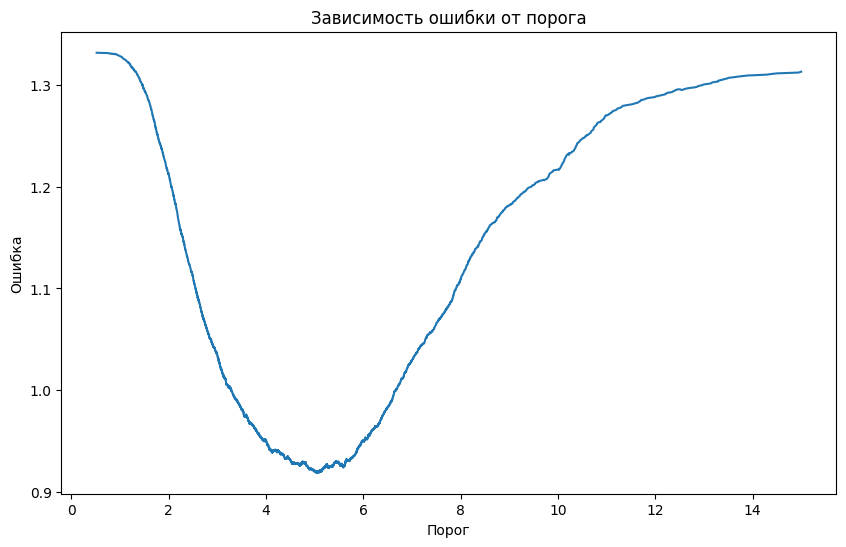

In [153]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
med = X["MedInc"].values
thresholds, criteria, thr, cr = find_best_split(med, y, "regression", "real")
err = np.var(y) - criteria   # делаем так потому что нужна ошибка, хотя иначе могли бы просто смотреть на пик

plt.figure(figsize=(10, 6))
plt.plot(thresholds, err)
plt.xlabel("Порог")
plt.ylabel("Ошибка")
plt.title("Зависимость ошибки от порога")
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [154]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
best_feat = ''
best_thr = 0
best_q = -1000000
for el in X.columns:
    _, _, opt_t, opt_q = find_best_split(X[el], y, "regression")
    if opt_t is not None and opt_q > best_q:
        best_q = opt_q
        best_feat = el
        best_thr = opt_t
print(best_feat, best_thr)

MedInc 5.03515


Ну все получается лучше всего делить MedInc с порогом около 5, в целом на графике мы это и увидели

**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [155]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)
            if gini is None:
                continue
            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = (feature_vector <= threshold)
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = (feature_vector == threshold)
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return
        if feature_best in self._feature_importances:
            self._feature_importances[feature_best] += gini_best
        else:
            self._feature_importances[feature_best] = gini_best
        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
            return node["class"]

        if self._feature_types[node["feature_split"]] == "real":
            if x[node["feature_split"]] <= node["threshold"]:
                return self._predict_node(x, node["left_child"])
            return self._predict_node(x, node["right_child"])
        else:
            if x[node["feature_split"]] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            return self._predict_node(x, node["right_child"])


    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)
        for key in self._feature_importances:
            self._feature_importances[key] /= sum(self._feature_importances.values())
    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)
    def feature_importances(self):
        return self._feature_importances

Касаемо важности тут все просто, мы знаем, что чтобы понять насколько важный признак следует посмотреть как он уменьшает нашу хаотичность, поэтому в fit_node мы как раз считаем важность признака, потому что как бы через него проходят все наши листья и мы можем указать, что важность мы будет счиать как улучшение критрии, мы уже успели найти лучшей признак через feature_best, так что просто добавлем джини, чтобы оченить его важность, в конце в fit мы просто нормализуем результаты, ну и создаем функцию в самом конце, но она ничего такого не делает, просто выводит нам результат

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

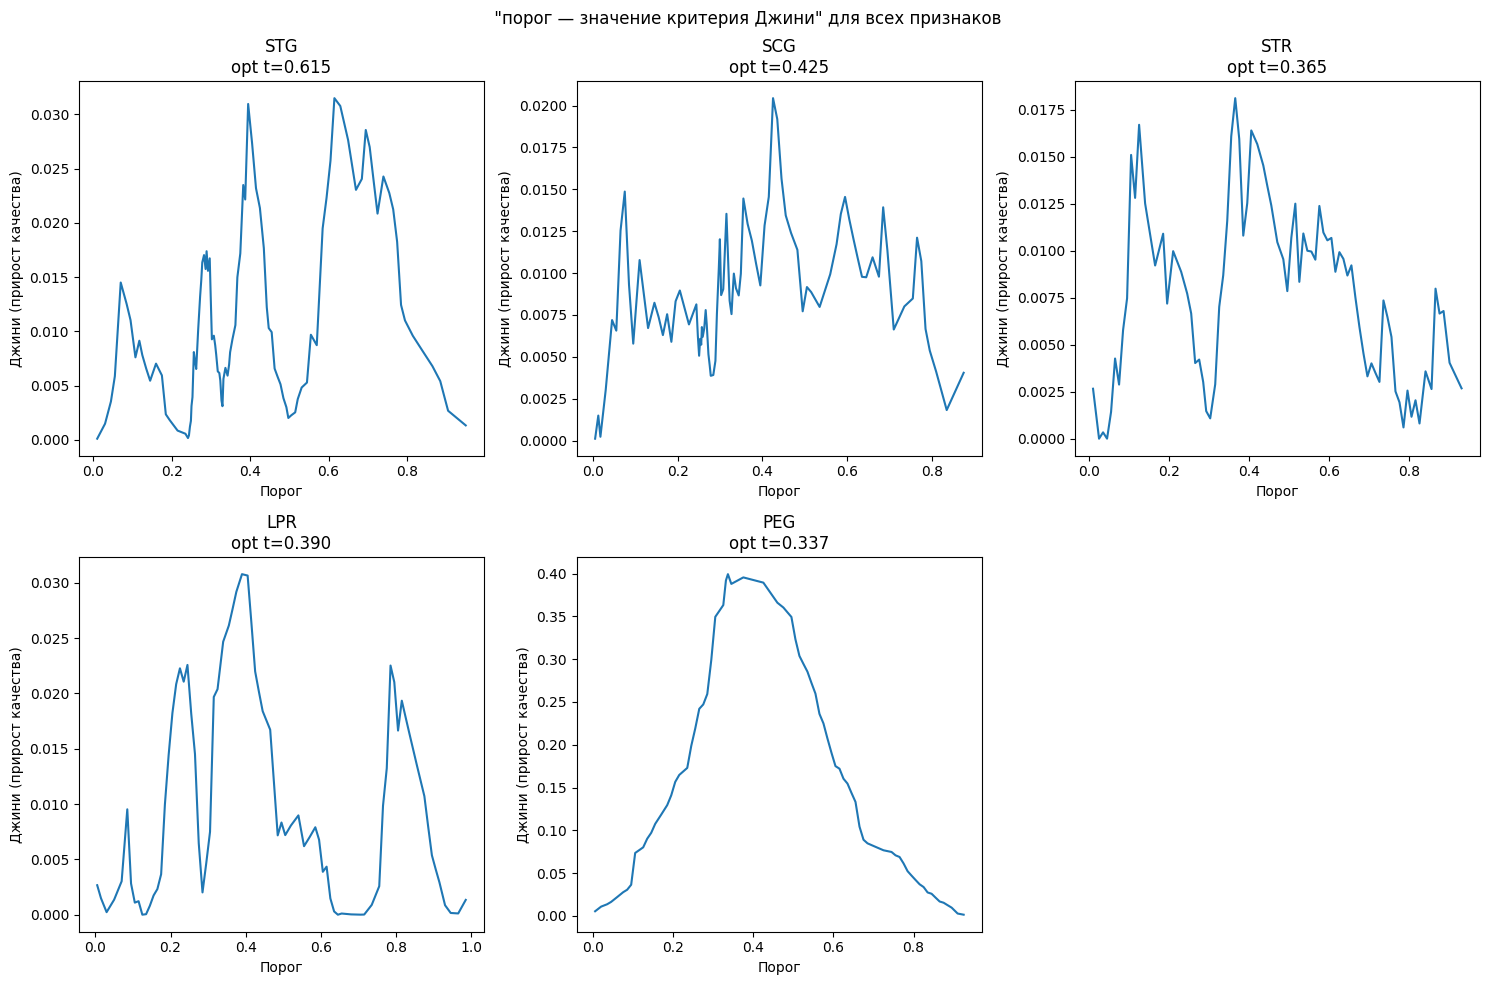

In [156]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
df = pd.read_csv('students.csv')
X = df.drop(df.columns[[0, -1]], axis=1)
y = df.iloc[:, -1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.reshape(-1)
for ax, f in zip(axes, X.columns):
    thr, crit, best_t, best_q = find_best_split(X[f].values, y.values, "classification", "real")
    ax.plot(thr, crit)
    ax.set_title(f"{f}\nopt t={best_t:.3f}")
    ax.set_xlabel("Порог")
    ax.set_ylabel("Джини (прирост качества)")
fig.delaxes(axes[-1])
fig.suptitle(' "порог — значение критерия Джини" для всех признаков')
plt.tight_layout()
plt.show()


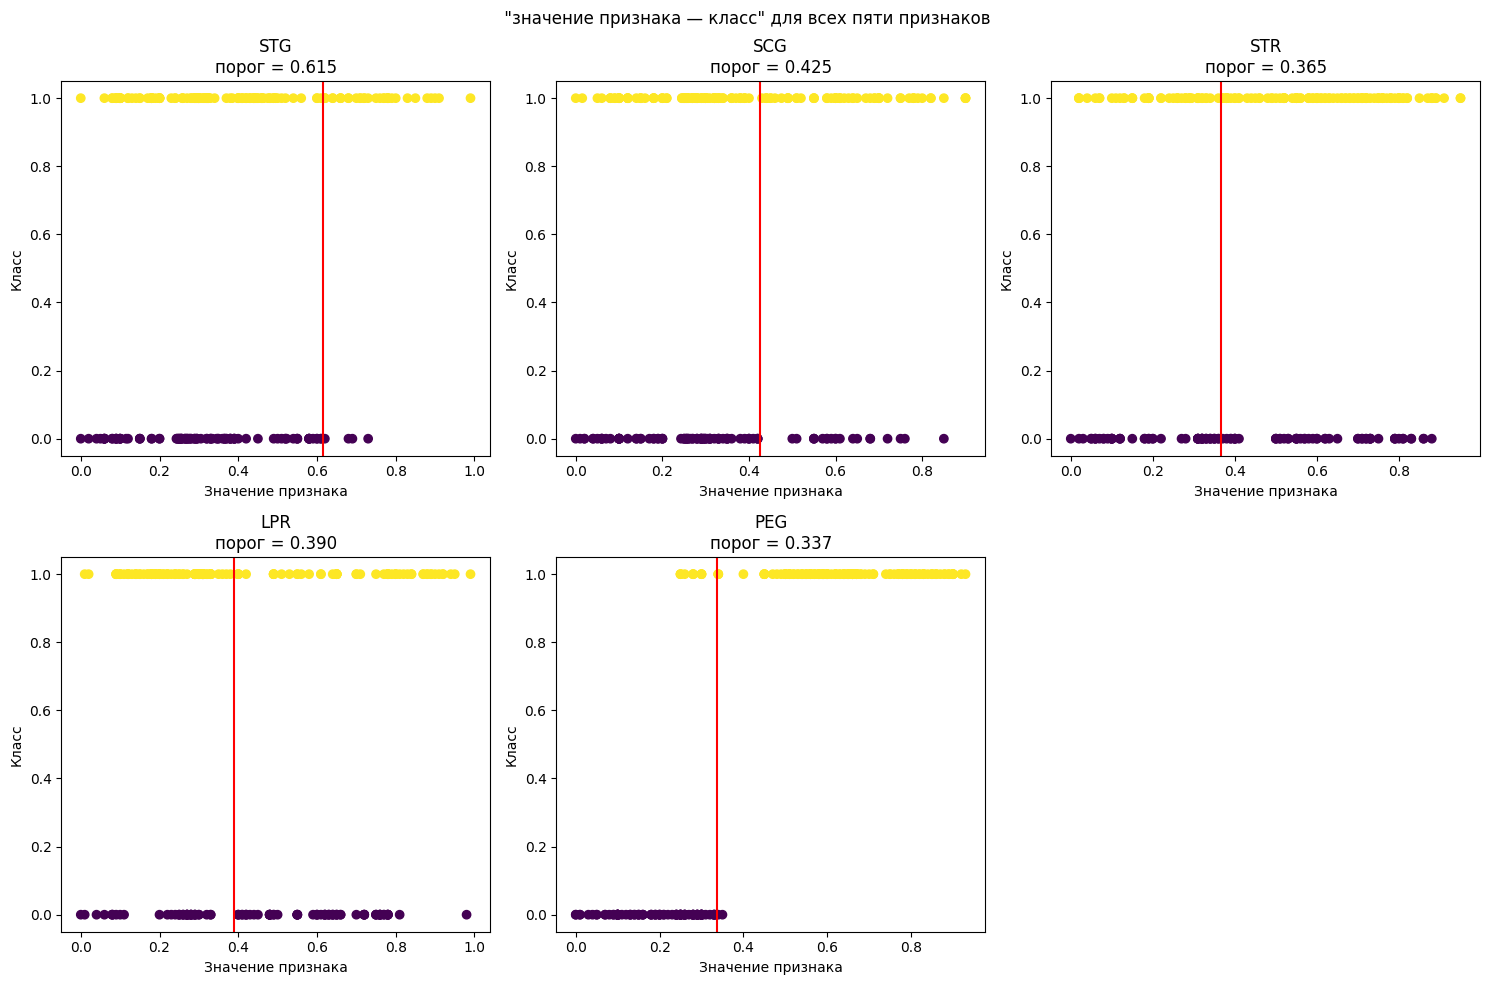

In [157]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.reshape(-1)

for ax, feature in zip(axes, X.columns):
    thr, crit, best_t, best_q = find_best_split(X[feature].values, y.values, "classification", "real")
    ax.scatter(X[feature], y, c=y)
    ax.axvline(x=best_t, color='red')
    ax.set_title(f"{feature}\nпорог = {best_t:.3f}")
    ax.set_xlabel("Значение признака")
    ax.set_ylabel("Класс")

fig.delaxes(axes[-1])
fig.suptitle(' "значение признака — класс" для всех пяти признаков')
plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

я предполагаю, что делить надо по признаку PEG, потому что у него один пик, то есть есть явно порог по которому лучше разделить, у остальных график скачет + видно, что значения критерия Джинни для него будет около 0.4 при оптимальном пороге, для остальных сильно ниже практически около 0, что учитывая нашу функцию, такое значение говорит о выской хаотичности. Это согласуется с диаграммой рассеяния, мы что мы легко можем разделить на классы PEG по порогу, потому что классу 0 соотвестуют почти все значения до порога, а классу 1 после в других графиках такого не наблюдается, распределение по классам практически равномерное. Вот получается, что как раз кривая для хорошего признака имеет максимум, который показывает, что по этому порогу получится хорошее разбиение, и тогда у нас будет лучше качество, а для плохих мы можем чуть увеличить значение качества, но у нас просто чуть разные значения при перешагивании между объектами, так в целом все равно у нас грубо говоря в маштабе будет плато с низкими значеним качества, а если смотреть на мои графики, то видим сильные колебания, которые в таком маштабе показывают лишь на совсем мизерные колебания в зависимости от порога

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [158]:
df1 = pd.read_csv('agaricus-lepiota.data')
from sklearn.preprocessing import LabelEncoder
for el in df1.columns:
    df1[el] = LabelEncoder().fit_transform(df1[el])
X = df1.drop(df1.columns[0], axis=1)
y = df1.iloc[:, 0]

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.5, random_state=67)
model = DecisionTree(feature_types=['categorical' for i in range(X.shape[1])])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

1.0


/tmp/ipykernel_2518/2435850374.py:72: RuntimeWarning: divide by zero encountered in divide
  p_right = right_counts / n_right[:, np.newaxis]
/tmp/ipykernel_2518/2435850374.py:75: RuntimeWarning: invalid value encountered in multiply
  crit_info = Hm - (n_left / n) * Hl - (n_right / n) * Hr


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [159]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [160]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

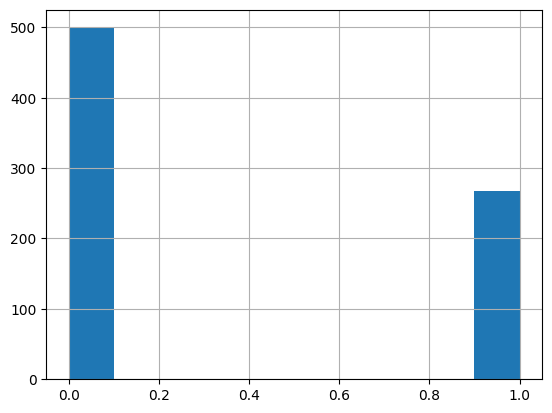

In [161]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [162]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_t, X_test, y_t, y_test = train_test_split(X, y, test_size = 0.3, random_state = 67)
X_train, X_val, y_train, y_val = train_test_split(X_t, y_t, test_size = 0.3, random_state = 67)

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [168]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
md_list = [1, 3, 5, 10, 50, 100, 1000]
msl_list = [1, 3, 5, 10, 50, 100, 150]
res = []
for el1 in md_list:
    for el2 in msl_list:
        model = DecisionTreeClassifier(max_depth=el1, min_samples_leaf=el2, random_state=67)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        f1 = f1_score(y_val, y_pred)
        res.append((el1, el2, f1))
best = max(res, key = lambda x: x[2])
print(best)
model = DecisionTreeClassifier(max_depth=best[0], min_samples_leaf=best[1], random_state=67)
model.fit(X_t, y_t)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), roc_auc_score(y_test, y_proba))

(1, 150, 0.6614173228346457)
0.7272727272727273 0.6575342465753424 0.5581395348837209 0.6928628708901363


Мы видим, что у нас самым оптимальным получается решающий пень, что не удивительно, ведь он точно не переобучается

**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [174]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
base_tree = DecisionTreeClassifier(max_depth=best[0], min_samples_leaf=best[1], random_state=67)
model = BaggingClassifier(estimator=base_tree, n_estimators=50, random_state=67)
model.fit(X_t, y_t)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), roc_auc_score(y_test, y_proba))

0.7575757575757576 0.7272727272727273 0.5581395348837209 0.8328789093825181


Мы видим, что у нас выросла точность, но так как точность и полнота зависят от порога разумнее всего смотреть на roc-auc и вот тут у нас достаточно значительный рост, в целом модель стала лучше, потому что мы, грубо гвооря, усреднили результаты 50 пней, даже не смотря на то, что у них и так маленький разброс нам удалось улучшить их

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

https://scikit-learn.ru/stable/modules/cross_validation.html#id3   шаблон как делать кросс валидацию отсюда

In [171]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.model_selection import cross_val_score
md_list = [1, 3, 5, 10, 50, 100, 1000]
mss_list = [3, 5, 10, 50, 100, 150]
res = []
for el1 in md_list:
    for el2 in mss_list:
        model = RandomForestClassifier(n_estimators=50, max_depth=el1, min_samples_split=el2, random_state=67)
        scores = cross_val_score(model, X_t, y_t, cv=5, scoring='f1')
        score = np.mean(scores)
        res.append((el1, el2, score))
best = max(res, key=lambda x: x[2])
print(best)
model = RandomForestClassifier(n_estimators=50, max_depth=best[0], min_samples_split=best[1], random_state=67)
model.fit(X_t, y_t)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), roc_auc_score(y_test, y_proba))

(50, 5, np.float64(0.6359140402976019))
0.7575757575757576 0.7678571428571429 0.5 0.8271852445870087


Оценивать опять разумнее всего по roc_auc, для рандом форест у нас получается самое большое значение, потому что мы уже рандомизируем не только объекты, но и признаки, в результате у нас получается более разные модели и мы сильнее уменьшаем разброс, поэтому итоговая модель получается лучше. еще видим, что тут у нас оптимальными оказались не пни, все таки мы разрешаем одной конкретной модели немного переобучиться, чтобы в итоге композиция была лучше

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

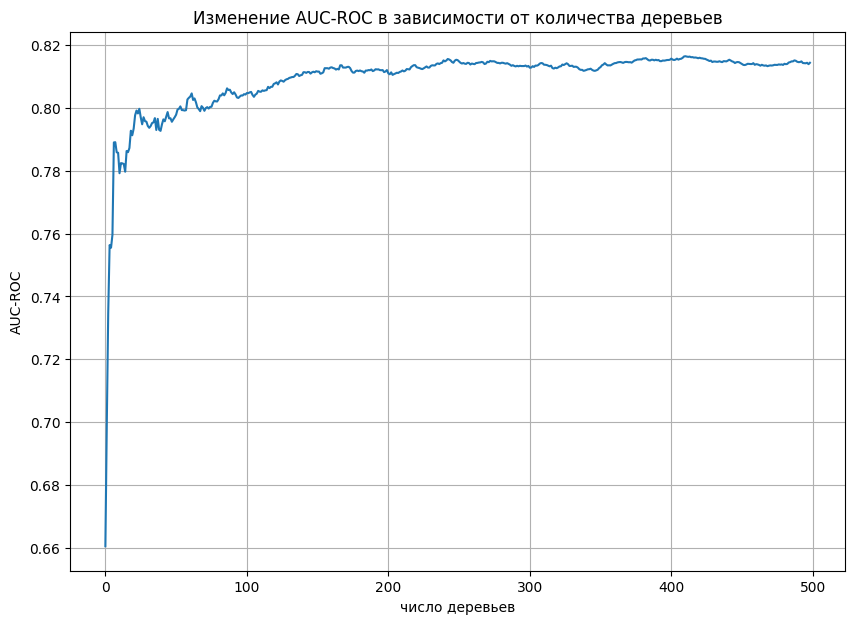

In [166]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
n_trees = 500
loss = []
for i in range(1, n_trees):
    model = RandomForestClassifier(n_estimators=i, random_state=67)
    model.fit(X_t, y_t)
    y_proba = model.predict_proba(X_test)[:, 1]
    loss.append(roc_auc_score(y_test, y_proba))

plt.figure(figsize=(10, 7))
plt.title("Изменение AUC-ROC в зависимости от количества деревьев")
plt.grid()
plt.plot(loss)
plt.ylabel("AUC-ROC")
plt.xlabel("число деревьев")
plt.show()

В целом мы видим, что есть рост примерно до 70 деревьев, а дальше выходим на плато, что ожидаемо, ведь из теории известно, что мы предполагаем, что случайный лес с ростом количества деревьев не переобучается, поэтому в целом кончено можно брать очень больше число деревьев, но будем долго обучаться, можно взять помоеньше и если это уже то число с которого мы выходим на плато, то мы ничего не потеряем

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

[0.08102059 0.28067407 0.0804654  0.06658008 0.06674034 0.17248922
 0.12985974 0.12217056]


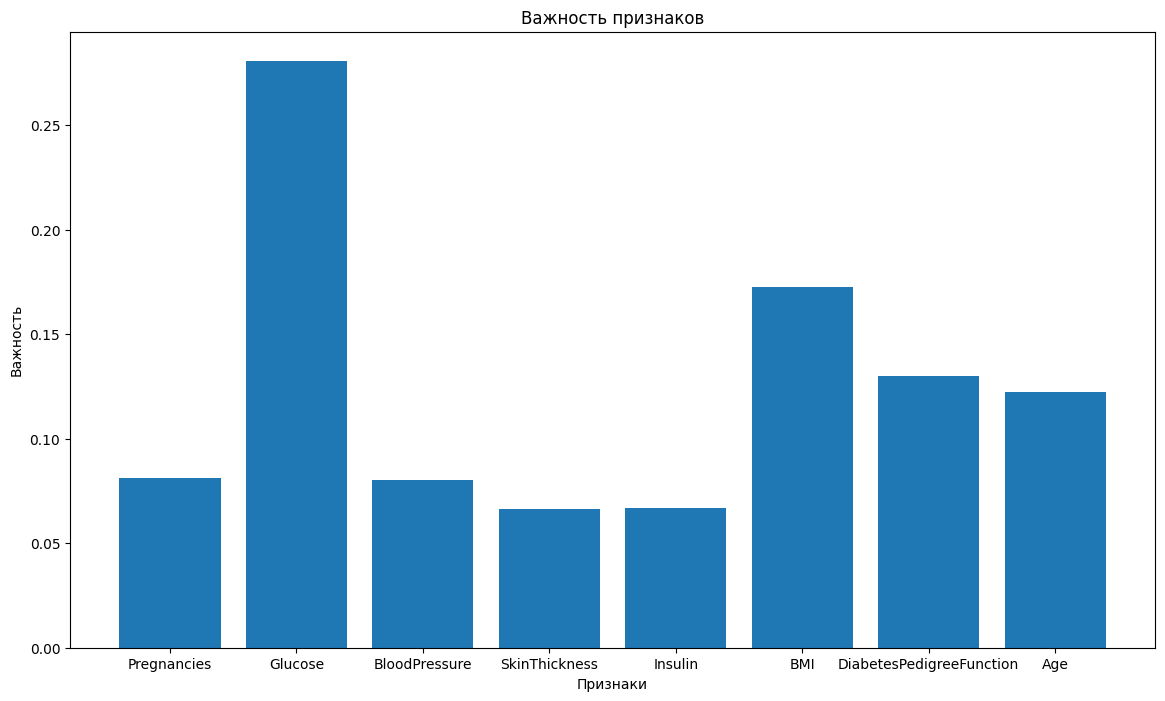

In [173]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
model = RandomForestClassifier(n_estimators=50, max_depth=best[0], min_samples_split=best[1], random_state=67)
model.fit(X_t, y_t)
print( model.feature_importances_)
plt.figure(figsize=(14, 8))
plt.bar(X.columns, model.feature_importances_)
plt.xlabel("Признаки")
plt.ylabel("Важность")
plt.title("Важность признаков")
plt.show()

Мы видим, что самой большой важность обладет признак Glucose, за ним следует признак BMI, но он обладает важность почти в 2 раза меньше, так что уверенным лидером оказвается Glucose